In [7]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [8]:
_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/cifar10/train', image_size=(32, 32), batch_size=64, shuffle=False, label_mode='int'
)

mean    = tf.zeros(3)
sq_mean = tf.zeros(3)
n_pixels = 0

for images, _ in _dataset:
    images   = tf.cast(images, tf.float32) / 255.0  # [0, 255] -> [0.0, 1.0]
    b, h, w, c = images.shape  # NHWC
    n_pixels += b * h * w
    mean     += tf.reduce_sum(images, axis=[0, 1, 2])  # N, H, W -> (C,)
    sq_mean  += tf.reduce_sum(images ** 2, axis=[0, 1, 2])

mean  /= n_pixels
std    = tf.sqrt(sq_mean / n_pixels - mean ** 2)  # Var(X) = E[X²] - E[X]²

MEAN = tuple(round(float(i), 4) for i in mean)
STD  = tuple(round(float(i), 4) for i in std)

MEAN, STD

Found 50000 files belonging to 10 classes.


((0.4914, 0.4822, 0.4465), (0.247, 0.2435, 0.2616))

In [9]:
MEAN = tf.constant([0.4914, 0.4822, 0.4465], dtype=tf.float32)
STD  = tf.constant([0.2470, 0.2435, 0.2616], dtype=tf.float32)

def train_transform(image, label):
    # Data Augmentation: 학습 데이터를 인위적으로 변경하여 다양성을 높인다.
    image = tf.cast(image, tf.float32) / 255.0

    # 상하좌우 64px zero-padding 후 랜덤 크롭, 물체 위치가 조금씩 달라진다.
    image = tf.pad(image, [[64, 64], [64, 64], [0, 0]])
    image = tf.image.random_crop(image, size=[415, 415, 3])

    # 50% 확률로 좌우 반전
    image = tf.image.random_flip_left_right(image)

    # 밝기 및 대비 ±20% 랜덤 변화
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # 채널별 정규화: (pixel - mean) / std
    image = (image - MEAN) / STD

    return image, label

In [11]:
# image_dataset_from_directory로 class 폴더 자동 인식
# validation_split으로 80/20 train/test 분리 (PyTorch random_split에 해당)
# batch_size=None: 개별 이미지로 로드 -> map() 함수가 (H, W, C) 단일 이미지를 받도록
train_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/pizza_not_pizza',
    image_size=(415, 415), batch_size=None, label_mode='int',
    validation_split=0.2, subset='training', seed=42
)
test_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/pizza_not_pizza',
    image_size=(415, 415), batch_size=None, label_mode='int',
    validation_split=0.2, subset='validation', seed=42
)

print(train_dataset.class_names)
print({name: idx for idx, name in enumerate(train_dataset.class_names)})

# map()으로 각 이미지에 transform 적용 후 batch
# prefetch(): 다음 batch를 background에서 미리 load -> GPU 대기 시간 감소
train_loader = train_dataset.shuffle(1000).map(train_transform, num_parallel_calls=tf.data.AUTOTUNE).batch(8).prefetch(tf.data.AUTOTUNE)
test_loader  = test_dataset.map(train_transform, num_parallel_calls=tf.data.AUTOTUNE).batch(8).prefetch(tf.data.AUTOTUNE)

Found 1966 files belonging to 2 classes.
Using 1573 files for training.
Found 1966 files belonging to 2 classes.
Using 393 files for validation.
['not_pizza', 'pizza']
{'not_pizza': 0, 'pizza': 1}


In [12]:
print(len(train_dataset), len(test_dataset))

1573 393


Found 1966 files belonging to 2 classes.


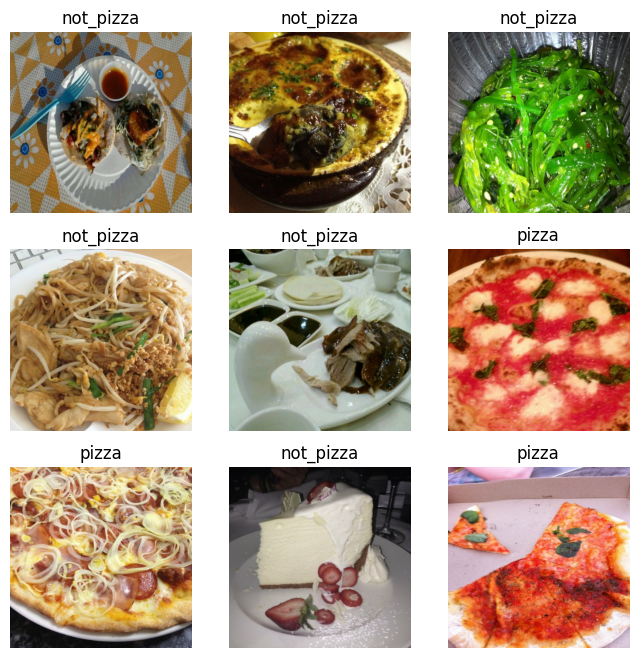

In [13]:
labels = {
    0: 'not_pizza',
    1: 'pizza'
}

pre = keras.utils.image_dataset_from_directory(
    '../datasets/pizza_not_pizza', image_size=(415, 415), batch_size=9, shuffle=True, label_mode='int'
)

sample_images, sample_labels = next(iter(pre))

figure = plt.figure(figsize=(8, 8))
for i in range(9):
    img   = sample_images[i].numpy().astype(np.uint8)
    label = sample_labels[i].numpy()
    figure.add_subplot(3, 3, i + 1)
    plt.title(labels[label])
    plt.axis('off')
    plt.imshow(img)

plt.show()